# Notebook 6 - White Light Preparation

We now need to create the final white light curve, taking into account the wavelength ranges we considered in #5, the resampling and the wavelength solution. We also need to standardize the ancillary data.

In [7]:
%matplotlib inline

If wanting to interact directly with plots

In [3]:
%matplotlib widget

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import reduction_utils.wavelength_calibration as wc

Define the contact points and wavelength range as used in notebook 5:

In [5]:
contact1 = 14
contact4 = 39
min_wvl = 3400
max_wvl = 7300

Load in the data:

In [6]:
parent_direc = '/Users/u2257755/Library/CloudStorage/OneDrive-UniversityofWarwick/LRG_BEASTS/WASP-168/2023-01-25/reduction_testing_fixed_30_mask_FWHM/'

star1_flux = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/star1_flux_resampled.pickle','rb'))
star2_flux = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/star2_flux_resampled.pickle','rb'))
error1 = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/star1_error_resampled.pickle','rb'))
error2 = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/star2_error_resampled.pickle','rb'))
wvl_solution_1 = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/wavelength_solution.pickle','rb'))
mjd = pickle.load(open(parent_direc+'pickled_objects/mjd_time.pickle','rb'))
bad_frames = []  
good_frames = np.setdiff1d(np.arange(mjd.shape[0]), bad_frames)
mjd = mjd[good_frames]
am = pickle.load(open(parent_direc+'pickled_objects/airmass.pickle','rb'))
am = am[good_frames]
exp_times = pickle.load(open(parent_direc+'pickled_objects/exposure_times.pickle','rb'))
exp_times = exp_times[good_frames]
xpos1 = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/xpos1_resampled.pickle','rb'))
sky1 = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/sky1_resampled.pickle','rb'))
fwhm1 = pickle.load(open(parent_direc+'pickled_objects/fwhm_1.pickle','rb'))
fwhm1 = fwhm1[good_frames]
xpos2 = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/xpos2_resampled.pickle','rb'))
sky2 = pickle.load(open(parent_direc+'pickled_objects/improved_resampling/sky2_resampled.pickle','rb'))
fwhm2 = pickle.load(open(parent_direc+'pickled_objects/fwhm_2.pickle','rb'))
fwhm2 = fwhm2[good_frames]

Load in y shifts, as calculated from 3_spectra_resampling.ipynb

In [8]:
ypos1 = pickle.load(open(parent_direc+'pickled_objects/ypos1.pickle','rb'))
ypos1_smooth = pickle.load(open(parent_direc+'pickled_objects/ypos1_smooth.pickle','rb'))
ypos2 = pickle.load(open(parent_direc+'pickled_objects/ypos2.pickle','rb'))
ypos2_smooth = pickle.load(open(parent_direc+'pickled_objects/ypos2_smooth.pickle','rb'))

Define time as fractional days:

In [9]:
time = mjd - int(mjd[0])
print('Time: ',time)

Time:  [0.13466941 0.13769035 0.14070967 0.14372968 0.14675143 0.14977145
 0.15279505 0.15581669 0.15883577 0.16185637 0.16487928 0.16789871
 0.17092348 0.17394488 0.17696501 0.17999105 0.18301442 0.1860393
 0.18906487 0.1920813  0.19510235 0.19812607 0.20114805 0.20417409
 0.20719711 0.21021794 0.21323876 0.21625959 0.21928017 0.22229891
 0.22532205 0.22834114 0.2313637  0.23438823 0.23740963 0.24043115
 0.24344687 0.2464677  0.24948852 0.25250842 0.2555282  0.25854624
 0.2615666  0.26458975 0.26761416 0.27063464 0.27365535 0.279697
 0.28271632 0.28573853 0.28875739 0.29177995 0.29479869 0.29782148
 0.30084311 0.30386359 0.3068843  0.3099057  0.31292653 0.3159455
 0.32198854 0.32500971]


Rescale sky for differing exposure times:

In [10]:
sky1 = np.array([i/j for i,j in zip(sky1,exp_times)])
sky2 = np.array([i/j for i,j in zip(sky2,exp_times)])

As before, remove frame 5 and cut at frame 84

In [11]:
start_idx = 0
end_idx = -1
if end_idx == -1:
    end_idx = None

star1_flux = np.vstack((star1_flux[start_idx:end_idx]))
star2_flux = np.vstack((star2_flux[start_idx:end_idx]))

error1 = np.vstack((error1[start_idx:end_idx]))
error2 = np.vstack((error2[start_idx:end_idx]))

mjd = np.hstack((mjd[start_idx:end_idx]))

time = np.hstack((time[start_idx:end_idx]))

exp_times = np.hstack((exp_times[start_idx:end_idx]))

sky1 = np.vstack((sky1[start_idx:end_idx]))
sky2 = np.vstack((sky2[start_idx:end_idx]))

xpos1 = np.vstack((xpos1[start_idx:end_idx]))
xpos2 = np.vstack((xpos2[start_idx:end_idx]))

fwhm1 = np.hstack((fwhm1[start_idx:end_idx]))
fwhm2 = np.hstack((fwhm2[start_idx:end_idx]))

ypos1 = np.hstack((ypos1[start_idx:end_idx]))
ypos2 = np.hstack((ypos2[start_idx:end_idx]))

ypos1_smooth = np.hstack((ypos1_smooth[start_idx:end_idx]))
ypos2_smooth = np.hstack((ypos2_smooth[start_idx:end_idx]))

am = np.hstack((am[start_idx:end_idx]))

nframes = len(star1_flux)

print('star1_flux:',np.shape(star1_flux),'error1: ',np.shape(error1),'mjd: ',np.shape(mjd),'time: ',np.shape(time),'exp_times: ',np.shape(exp_times),'sky1: ',np.shape(sky1),'xpos1: ',np.shape(xpos1),'fwhm1: ',np.shape(fwhm1),'ypos1: ',np.shape(ypos1),'am: ',np.shape(am))

star1_flux: (62, 961) error1:  (62, 961) mjd:  (62,) time:  (62,) exp_times:  (62,) sky1:  (62, 961) xpos1:  (62, 961) fwhm1:  (62,) ypos1:  (62,) am:  (62,)


Now cut only consider the wavelength range used for the spectroscopic light curves:

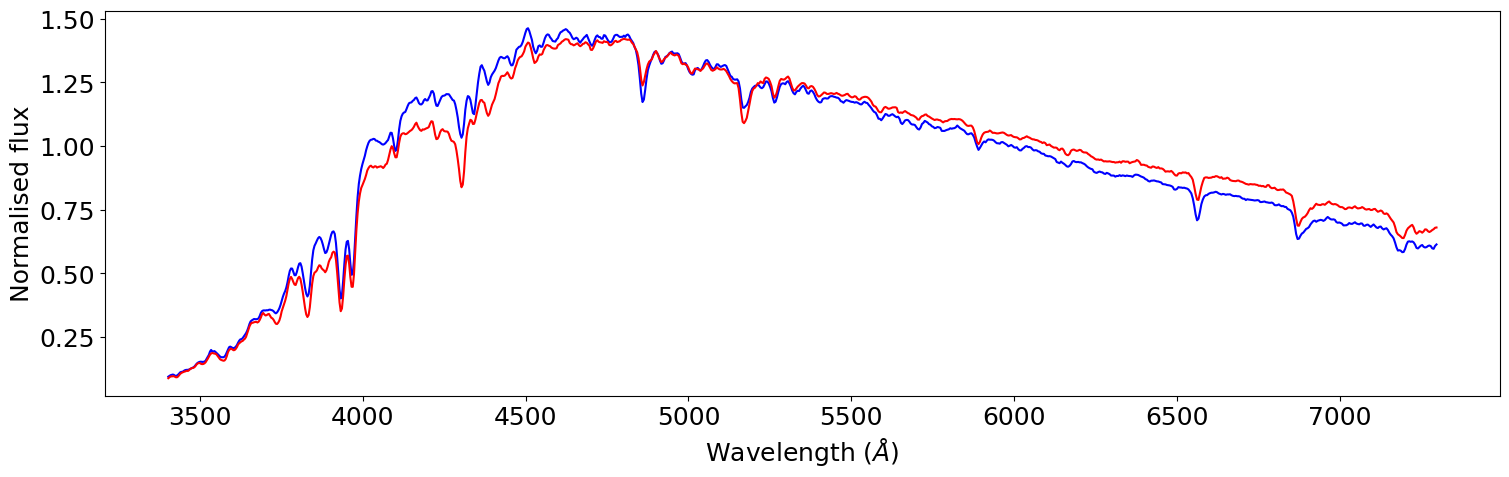

In [12]:
blue_mask = wvl_solution_1 < min_wvl
red_mask = wvl_solution_1 > max_wvl
combined_mask = blue_mask + red_mask

# Invert the mask
combined_mask = ~combined_mask

plt.figure(figsize=(18, 5))
plt.plot(wvl_solution_1[combined_mask],wc.normalise(star1_flux[nframes//2][combined_mask]),'b')
plt.plot(wvl_solution_1[combined_mask],wc.normalise(star2_flux[nframes//2][combined_mask]),'r')
plt.xlabel('Wavelength ($\AA$)')
plt.ylabel('Normalised flux')
plt.show()

And perform the cut:

In [13]:
s1 = star1_flux[:,combined_mask]
s2 = star2_flux[:,combined_mask]

e1 = error1[:,combined_mask]
e2 = error2[:,combined_mask]

sky1 = sky1[:,combined_mask]
xpos1 = xpos1[:,combined_mask]

sky2 = sky2[:,combined_mask]
xpos2 = xpos2[:,combined_mask]

wvl = wvl_solution_1[combined_mask]

Now create the white light curve, normalise to the out of transit data and plot:

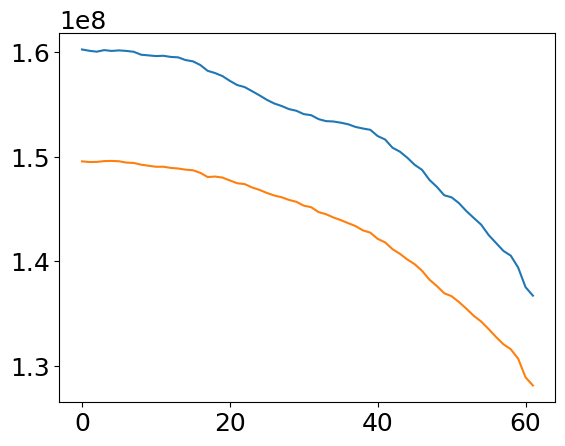

In [14]:
plt.plot(np.sum(s1,axis=1))
plt.plot(np.sum(s2,axis=1))

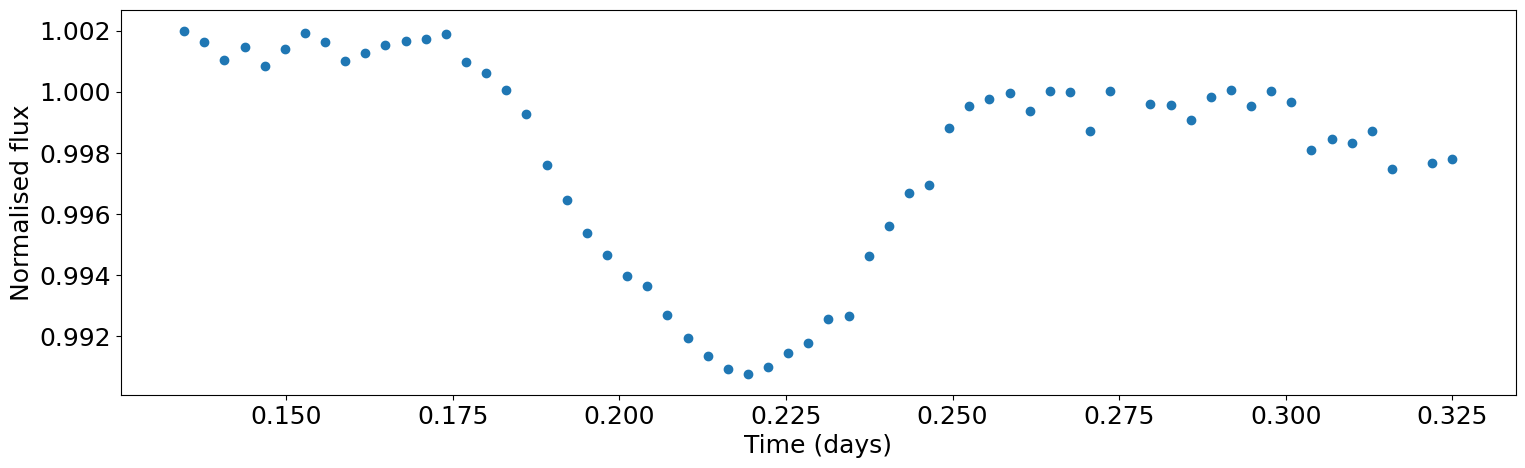

In [15]:
ratio = np.sum(s1,axis=1)/np.sum(s2,axis=1)
err_ratio = np.sqrt((np.sqrt(np.sum(e1**2,axis=1))/np.sum(s1,axis=1))**2 \
                    + (np.sqrt(np.sum(e2**2,axis=1))/np.sum(s2,axis=1))**2)*ratio


flux = ratio/np.median(ratio[:contact1].tolist()+ratio[contact4:].tolist())
error = (err_ratio/ratio) * flux

plt.figure(figsize=(18, 5))
plt.errorbar(time,flux,yerr=error,fmt='o',ecolor='k',capsize=0)
plt.ylabel('Normalised flux')
plt.xlabel('Time (days)')
plt.show()

And save the output:

In [16]:
import os
os.makedirs(parent_direc+'pickled_objects/WL/',exist_ok=True)

pickle.dump(flux,open(parent_direc+'pickled_objects/WL/white_light_flux.pickle','wb'))
pickle.dump(error,open(parent_direc+'pickled_objects/WL/white_light_error.pickle','wb'))

Now combine and standardize the ancillary data for use in the fitting process.  This is done via subtracting the mean and dividing by the standard deviation.

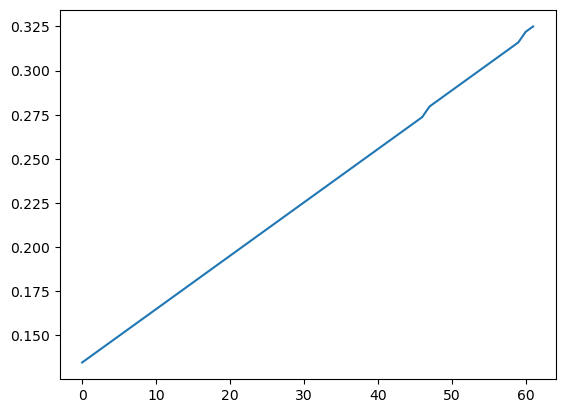

In [16]:
plt.plot(time)

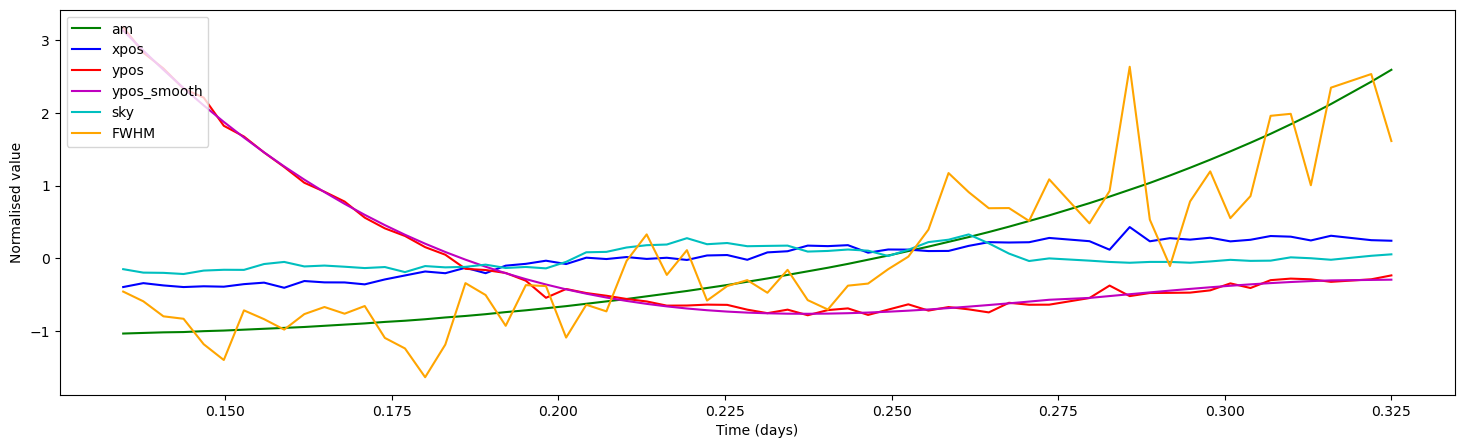

In [17]:

xpos1_norm = (xpos1.mean(axis=1)-xpos1.mean())/xpos1.std()
xpos2_norm = (xpos2.mean(axis=1)-xpos2.mean())/xpos2.std()

xpos = np.mean((xpos1_norm,xpos2_norm),axis=0)

ypos1_norm = (ypos1-ypos1.mean())/ypos1.std()
ypos2_norm = (ypos2-ypos2.mean())/ypos2.std()

# combine ypos into a single array from star 1 and star 2
ypos = np.mean((ypos1_norm,ypos2_norm),axis=0)


ypos1_smooth_norm = (ypos1_smooth-ypos1_smooth.mean())/ypos1_smooth.std()
ypos2_smooth_norm = (ypos2_smooth-ypos2_smooth.mean())/ypos2_smooth.std()

# combine ypos_smooth into a single array from star 1 and star 2
ypos_smooth  = np.mean((ypos1_smooth_norm,ypos2_smooth_norm),axis=0)

sky1_norm = (sky1.mean(axis=1)-sky1.mean())/sky1.std()
sky2_norm = (sky2.mean(axis=1)-sky2.mean())/sky2.std()

sky = np.mean((sky1_norm,sky2_norm),axis=0)

fwhm1_norm = (fwhm1-fwhm1.mean())/fwhm1.std()
fwhm2_norm = (fwhm2-fwhm2.mean())/fwhm2.std()

fwhm = np.mean((fwhm1_norm,fwhm2_norm),axis=0)

am_norm = (am-am.mean())/am.std()

plt.figure(figsize=(18, 5))
plt.plot(time,am_norm,'g',label='am')
plt.plot(time,xpos,'b',label='xpos')
plt.plot(time,ypos,'r',label='ypos')
plt.plot(time,ypos_smooth,'m',label='ypos_smooth')
plt.plot(time,sky,'c',label='sky')
plt.plot(time,fwhm,'orange',label='FWHM')
plt.xlabel('Time (days)')
plt.ylabel('Normalised value')
plt.legend(loc='upper left')
plt.show()

#fwhm_norm.pickle,xpos_norm.pickle,ypos_norm.pickle,am_norm.pickle,sky_norm.pickle

And save the output:

In [18]:
pickle.dump(am_norm,open(parent_direc+'pickled_objects/WL/am_norm.pickle','wb'))
pickle.dump(fwhm,open(parent_direc+'pickled_objects/WL/fwhm_norm.pickle','wb'))
pickle.dump(sky,open(parent_direc+'pickled_objects/WL/sky_norm.pickle','wb'))
pickle.dump(xpos,open(parent_direc+'pickled_objects/WL/xpos_norm.pickle','wb'))
pickle.dump(ypos,open(parent_direc+'pickled_objects/WL/ypos_norm.pickle','wb'))
pickle.dump(ypos_smooth,open(parent_direc+'pickled_objects/WL/ypos_smooth_norm.pickle','wb'))
pickle.dump(time,open(parent_direc+'pickled_objects/WL/time_norm.pickle','wb'))

In [26]:
time[28]

0.21928017000027467

We also want to calculate the central wavelength and wavelength range used for the white light curve to calculate the limb darkening coefficients.

In [19]:
wvl_centre = np.array([(max_wvl+min_wvl)//2])
wvl_error = np.array([max_wvl-min_wvl])
print(wvl_centre,wvl_error)

[5350] [3900]


And save:

In [20]:
pickle.dump(wvl_centre,open(parent_direc+'pickled_objects/WL/white_wvl_centre.pickle','wb'))
pickle.dump(wvl_error,open(parent_direc+'pickled_objects/WL/white_wvl_error.pickle','wb'))

Now we have spectroscopic and white light curves, we can fit the data!

0.0008649357177901531 -0.00402819149261872 -0.0009578846798833897


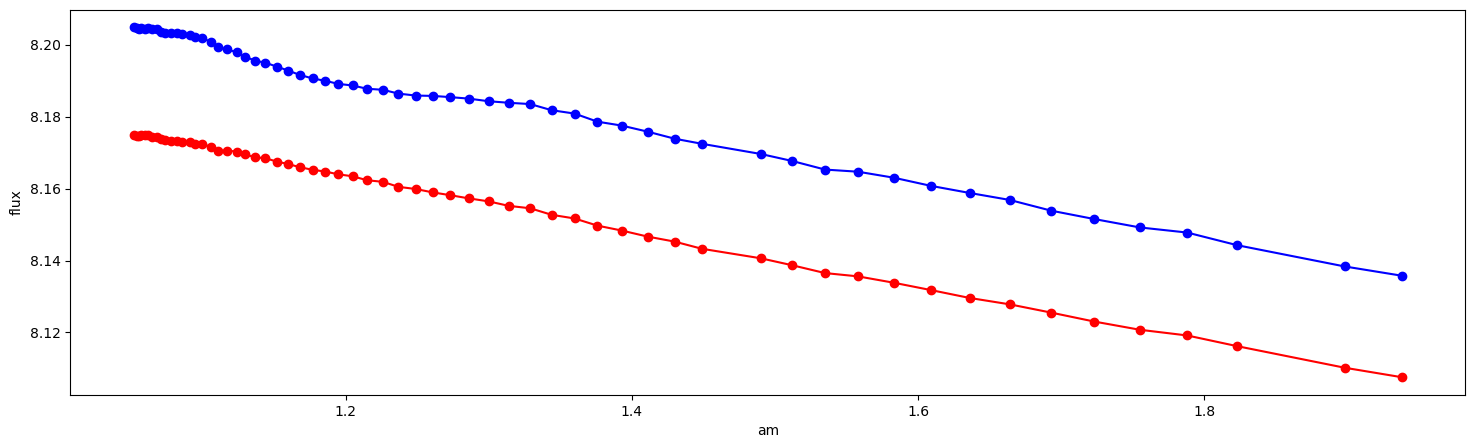

In [22]:
extinction = np.exp(-am)
extinction = np.log10(flux)
print(extinction[0],min(extinction),extinction[-1])

plt.figure(figsize=(18, 5))
plt.plot(am,np.log10(np.sum(s1,axis=1)),'b-o')
plt.plot(am,np.log10(np.sum(s2,axis=1)),'r-o')
plt.ylabel('flux')
plt.xlabel('am')
plt.show()

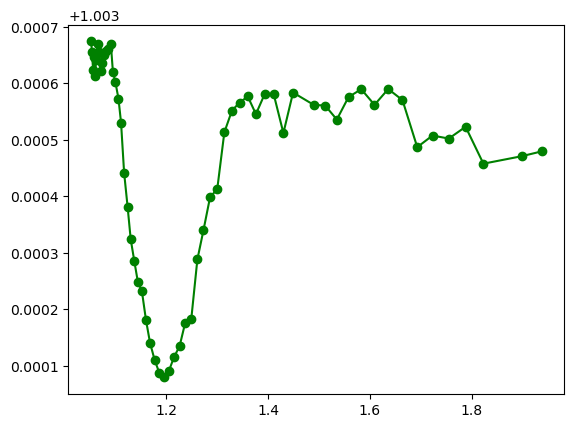

In [23]:
plt.plot(am,np.log10(np.sum(s1,axis=1))/np.log10(np.sum(s2,axis=1)),'g-o')

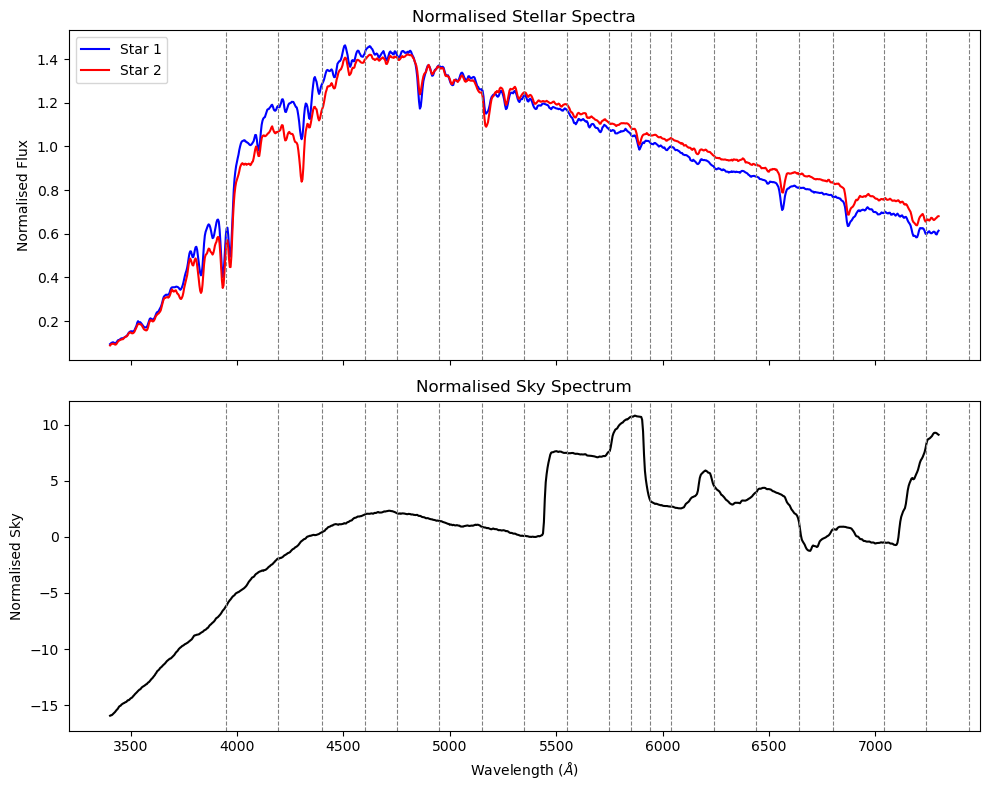

In [24]:
import matplotlib.pyplot as plt

# Prepare sky_other
sky1_norm_other = (sky1.mean(axis=0) - sky1.mean()) / sky1.std()
sky2_norm_other = (sky2.mean(axis=0) - sky2.mean()) / sky2.std()
sky_other = np.mean((sky1_norm_other, sky2_norm_other), axis=0)

# Define bin edges
bin_edges = [3950, 4190, 4400, 4600, 4750, 4950, 5150, 5350, 5550, 5750,
             5850, 5940, 6040, 6240, 6440, 6640, 6800, 7040, 7240, 7440]

# Set up figure with two vertical subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# First subplot: stellar fluxes
axs[0].plot(wvl_solution_1[combined_mask], wc.normalise(star1_flux[nframes//2][combined_mask]), 'b', label='Star 1')
axs[0].plot(wvl_solution_1[combined_mask], wc.normalise(star2_flux[nframes//2][combined_mask]), 'r', label='Star 2')
axs[0].set_ylabel('Normalised Flux')
axs[0].set_title('Normalised Stellar Spectra')
axs[0].legend()

# Second subplot: sky
axs[1].plot(wvl_solution_1[combined_mask], wc.normalise(sky_other), 'k')
axs[1].set_xlabel('Wavelength ($\AA$)')
axs[1].set_ylabel('Normalised Sky')
axs[1].set_title('Normalised Sky Spectrum')

# Add dashed vertical bin edge lines to both subplots
for ax in axs:
    for edge in bin_edges:
        ax.axvline(edge, linestyle='--', color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

#import reduction_utils.wavelength_binning as wb
#wb.plot_spectra(np.sum(s1,axis=1)[nframes//2],np.sum(s1,axis=1)[nframes//2],wvl_solution_1,\
#                bin_edges=bin_edges,ratio=True,save_fig=False,alkali=True,telluric=True)

TESTING EVIES METHOD

In [20]:
np.shape(star1_flux)

(62, 961)

In [ ]:
contact1 = 14
contact4 = 39
min_wvl = 3400
max_wvl = 7300

it = 

/var/folders/g6/_mwyc8411c51p5gg7gmnkt940000gp/T/ipykernel_13279/161723226.py:39: RuntimeWarning: invalid value encountered in divide
  ratio_each = star1_flux / star2_flux
/var/folders/g6/_mwyc8411c51p5gg7gmnkt940000gp/T/ipykernel_13279/161723226.py:46: RuntimeWarning: invalid value encountered in divide
  (error1 / star1_flux)**2 +
/var/folders/g6/_mwyc8411c51p5gg7gmnkt940000gp/T/ipykernel_13279/161723226.py:47: RuntimeWarning: invalid value encountered in divide
  (error2 / star2_flux)**2


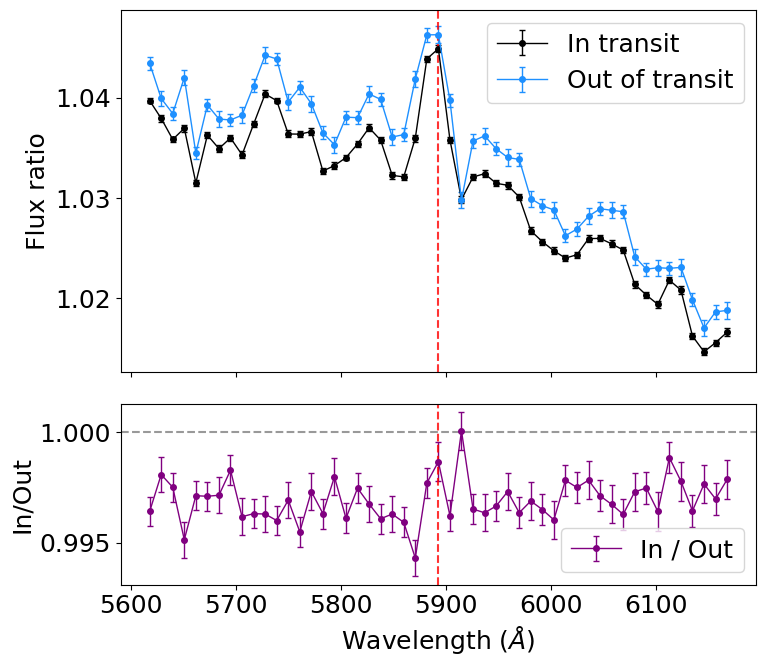

Saved sodium_ratio_of_ratios_test.txt


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import reduction_utils.wavelength_binning as wb
import reduction_utils.wavelength_calibration as wc

# =========================
# User inputs
# =========================
contact1 = 0          # first in-transit exposure index
contact4 = 50          # last in-transit exposure index
na_centre = 5893.0     # sodium doublet centre in Angstrom
bin_width_na = 11.0    # bin width in Angstrom
no_bins_na = 51        # total number of bins around sodium

# =========================
# Build in-transit / out-of-transit masks
# =========================
n_exp = star1_flux.shape[0]

in_mask = np.zeros(n_exp, dtype=bool)
in_mask[contact1:contact4+1] = True
out_mask = ~in_mask

# =========================
# Build sodium-region bins
# =========================
na_bins = np.arange(
    na_centre - (bin_width_na / 2.0) * no_bins_na,
    na_centre + (bin_width_na / 2.0) * (no_bins_na + 1),
    bin_width_na
)

na_bin_centres = 0.5 * (na_bins[:-1] + na_bins[1:])
na_bin_widths = na_bins[1:] - na_bins[:-1]

# =========================
# Ratio spectra per exposure
# =========================
ratio_each = star1_flux / star2_flux

# Optional propagated errors if available
have_errors = ('error1' in globals()) and ('error2' in globals())

if have_errors:
    ratio_err_each = ratio_each * np.sqrt(
        (error1 / star1_flux)**2 +
        (error2 / star2_flux)**2
    )

# =========================
# Bin the spectra
# =========================
binned_in = np.full(no_bins_na, np.nan)
binned_out = np.full(no_bins_na, np.nan)
err_in = np.full(no_bins_na, np.nan)
err_out = np.full(no_bins_na, np.nan)

for i in range(no_bins_na):
    lo = na_bins[i]
    hi = na_bins[i+1]
    m = (wvl_solution_1 >= lo) & (wvl_solution_1 < hi)

    if np.any(m):
        # average ratio in wavelength for each exposure
        per_exp_bin = np.mean(ratio_each[:, m], axis=1)

        in_vals = per_exp_bin[in_mask]
        out_vals = per_exp_bin[out_mask]

        binned_in[i] = np.mean(in_vals)
        binned_out[i] = np.mean(out_vals)

        if have_errors:
            per_exp_bin_err = np.sqrt(np.sum(ratio_err_each[:, m]**2, axis=1)) / np.sum(m)
            err_in[i] = np.sqrt(np.sum(per_exp_bin_err[in_mask]**2)) / np.sum(in_mask)
            err_out[i] = np.sqrt(np.sum(per_exp_bin_err[out_mask]**2)) / np.sum(out_mask)
        else:
            if len(in_vals) > 1:
                err_in[i] = np.std(in_vals, ddof=1) / np.sqrt(len(in_vals))
            if len(out_vals) > 1:
                err_out[i] = np.std(out_vals, ddof=1) / np.sqrt(len(out_vals))

# =========================
# Ratio-of-ratios
# =========================
ratio_of_ratios = binned_in / binned_out

# Propagate uncertainties:
# z = a / b
# (sigma_z / z)^2 = (sigma_a / a)^2 + (sigma_b / b)^2
ratio_of_ratios_err = ratio_of_ratios * np.sqrt(
    (err_in / binned_in)**2 +
    (err_out / binned_out)**2
)

# =========================
# Plot all three if wanted
# =========================
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Top panel: in/out separately
axes[0].errorbar(
    na_bin_centres, binned_in, yerr=err_in,
    fmt='o-', color='k', ms=4, lw=1, capsize=2,
    label='In transit'
)
axes[0].errorbar(
    na_bin_centres, binned_out, yerr=err_out,
    fmt='o-', color='dodgerblue', ms=4, lw=1, capsize=2,
    label='Out of transit'
)
axes[0].axvline(na_centre, color='red', linestyle='--', alpha=0.8)
axes[0].set_ylabel('Flux ratio')
axes[0].legend()

# Bottom panel: ratio-of-ratios
axes[1].errorbar(
    na_bin_centres, ratio_of_ratios, yerr=ratio_of_ratios_err,
    fmt='o-', color='purple', ms=4, lw=1, capsize=2,
    label='In / Out'
)
axes[1].axhline(1.0, color='grey', linestyle='--', alpha=0.8)
axes[1].axvline(na_centre, color='red', linestyle='--', alpha=0.8)
axes[1].set_xlabel(r'Wavelength ($\AA$)')
axes[1].set_ylabel('In/Out')
axes[1].legend()

plt.tight_layout()
plt.show()

# =========================
# Save outputs
# =========================
output = np.column_stack([
    na_bin_centres,
    na_bin_widths,
    binned_in,
    err_in,
    binned_out,
    err_out,
    ratio_of_ratios,
    ratio_of_ratios_err
])

header = (
    "wavelength_centre_A bin_width_A "
    "in_transit_ratio in_transit_err "
    "out_transit_ratio out_transit_err "
    "in_over_out in_over_out_err"
)

np.savetxt("sodium_ratio_of_ratios_test.txt", output, header=header)
print("Saved sodium_ratio_of_ratios_test.txt")